<a href="https://colab.research.google.com/github/amulyasingabhattu11/fitnessWatchesPricePrediction/blob/main/fitness_watches_ml_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 FitWatch ML — Price Predictor
### Train, Evaluate & Deploy a smartwatch price prediction model via Flask + ngrok

> **Updated notebook — changes aligned with EDA review:**
> - **FIXED:** Feature prep now reads one-hot columns (from updated EDA) instead of `*_encoded` LabelEncoder columns
> - **FIXED:** Encoding-map cell replaced — maps are derived directly from one-hot column names (no LabelEncoder re-fit needed)
> - **FIXED:** Sanity-test cell moved to *after* model training (used `best_model` before it was defined)
> - **FIXED:** Residual plot added alongside Actual vs Predicted (helps diagnose heteroscedasticity)
> - **FIXED:** Cross-validation scores added to complement hold-out metrics
> - **FIXED:** Flask UI chip `data-brand` / `data-parent` values updated to reflect one-hot encoding (feature names, not integer codes)
> - **IMPROVED:** `sns.set_theme` applied; all axes carry ₹ units; model comparison chart labelled consistently

## **STEP 1 — Install dependencies**

In [1]:
!pip install lightgbm catboost pyngrok flask xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


## **STEP 2 — Mount Drive & Load ML-ready dataset**

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb
import catboost as cb

from google.colab import drive
drive.mount('/content/drive')

# FIXED: load the ML-ready CSV produced by the *updated* EDA notebook
# (which uses pd.get_dummies one-hot encoding, not LabelEncoder integer codes)
df = pd.read_csv("/content/drive/MyDrive/fitness_watches_ml_ready.csv",
                 encoding='utf-8-sig')

sns.set_theme(style='whitegrid')   # consistent plot style
plt.rcParams['figure.dpi'] = 100

print(f'✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
display(df.info())
df.head()

Mounted at /content/drive
✅ Loaded: 73 rows × 22 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   73 non-null     object 
 1   Brand                  73 non-null     object 
 2   Current Price          73 non-null     float64
 3   Original Price         73 non-null     float64
 4   Discount %             73 non-null     float64
 5   Strap Colour           73 non-null     object 
 6   Strap Type             73 non-null     object 
 7   Display Size           73 non-null     object 
 8   Display Type           73 non-null     object 
 9   Calorie Count          73 non-null     bool   
 10  Step Count             73 non-null     bool   
 11  Heart Rate Monitor     73 non-null     bool   
 12  Health Features        73 non-null     object 
 13  Smart Functions        73 non-null     object 
 14  bra

None

,Name,Brand,Current Price,Original Price,Discount %,Strap Colour,Strap Type,Display Size,Display Type,Calorie Count,...,Health Features,Smart Functions,brand,parent_company,Calculated Discount %,Discount Suspicious,Display Size (inches),Health Feature Count,Smart Feature Count,Price Anomaly
0,"RGV H9 BT Calling, Fitness tracking Multiple W...",RGV,682.0,691.0,85.0,Black,Metal,"8""",AMOLED,True,...,"Calorie Count, Step Count, Heart Rate, SpO2, S...",BT Calling,RGV,RGV,1.3,True,8.0,5,1,False
1,Nikki Trades Gen 9 Model Fitness Health Music ...,Nikki,1470.0,4999.0,84.0,Black,Metal,"8""",AMOLED,True,...,"Calorie Count, Step Count, Heart Rate, Sleep M...",BT Calling,Nikki,Nikki,70.6,False,8.0,4,1,False
2,"GOBOULT Drift BT Calling HD Display, 140+ Watc...",GOBOULT,879.0,1449.0,85.0,Black,Metal,"8""",AMOLED,False,...,Heart Rate,"BT Calling, Voice Assistant",GOBOULT,GOBOULT,39.3,True,8.0,1,2,False
3,"GameSir IPS HD Round Bluetooth Calling, 120 Sp...",GameSir,1199.0,1599.0,93.0,Black,Metal,"8""",AMOLED,True,...,"Calorie Count, Step Count, Heart Rate, SpO2, S...","BT Calling, Voice Assistant",GameSir,GameSir,25.0,True,8.0,5,2,False
4,sweetex Rose Gold Smart Watch Bluetooth Callin...,sweetex,1470.0,1509.0,70.0,Black,Metal,"8""",AMOLED,False,...,Heart Rate,"BT Calling, Voice Assistant",sweetex,Sweetex,2.6,True,8.0,1,2,False


## **STEP 3 — Prepare Features & Target**

> **FIXED:** The original notebook expected `Brand_encoded`, `Strap Type_encoded`, etc. —
> integer codes produced by `LabelEncoder`. The updated EDA notebook uses `pd.get_dummies`
> instead, which creates binary one-hot columns such as `Brand_Fastrack`, `Brand_GameSir`, …
> This cell now auto-detects whichever encoding scheme is present so the notebook works with
> both the old and new EDA output.

In [3]:
# ── Numeric / boolean features (always present) ───────────────────────────
base_features = [
    'Health Feature Count',
    'Smart Feature Count',
    'Calorie Count',
    'Step Count',
    'Heart Rate Monitor',
]

# Convert boolean columns to int (True→1, False→0)
for col in ['Calorie Count', 'Step Count', 'Heart Rate Monitor']:
    if col in df.columns:
        df[col] = df[col].astype(int)

# ── Auto-detect encoding scheme ────────────────────────────────────────────
# Updated EDA  → one-hot columns  e.g. Brand_Fastrack, Strap Type_Metal …
# Original EDA → integer columns  e.g. Brand_encoded, Strap Type_encoded …
ohe_cols     = [c for c in df.columns if any(
    c.startswith(pfx) for pfx in ['Brand_', 'Strap Type_', 'Display Type_', 'parent_company_']
)]
legacy_cols  = [c for c in ['Brand_encoded', 'Strap Type_encoded',
                             'Display Type_encoded', 'parent_company_encoded']
                if c in df.columns]

cat_features = ohe_cols if ohe_cols else legacy_cols
encoding_mode = 'one-hot' if ohe_cols else 'label-encoded'
print(f'Encoding mode detected: {encoding_mode}')
print(f'Categorical features ({len(cat_features)}): {cat_features[:8]} …')

feature_cols = [c for c in base_features + cat_features if c in df.columns]

target_col = 'Current Price'
X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with any NaN in features or target
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

# Store column order — everything downstream must respect this
feature_columns = X.columns.tolist()

print(f'\nFeatures used   : {len(feature_columns)}')
print(f'Target          : {target_col}')
print(f'Training samples: {len(X)}')
display(X.head())

Encoding mode detected: label-encoded
Categorical features (0): [] …

Features used   : 5
Target          : Current Price
Training samples: 73


,Health Feature Count,Smart Feature Count,Calorie Count,Step Count,Heart Rate Monitor
0,5,1,1,1,1
1,4,1,1,1,1
2,1,2,0,0,1
3,5,2,1,1,1
4,1,2,0,0,1


### Encoding Reference Map

> **FIXED:** The original cell re-fitted `LabelEncoder` objects to print encoding maps,
> but the updated EDA uses one-hot encoding so there are no integer codes — each category
> is represented by its own binary column. This cell now prints the correct reference
> (column names for one-hot, or maps for label-encoded) depending on what was detected above.

In [4]:
if encoding_mode == 'one-hot':
    print('=== ONE-HOT COLUMN REFERENCE ===')
    print('The following binary columns were created by pd.get_dummies in the EDA notebook.')
    print('A value of 1 means that category is active; all others are 0.\n')
    for pfx in ['Brand_', 'Display Type_', 'Strap Type_', 'parent_company_']:
        cols = sorted([c for c in feature_columns if c.startswith(pfx)])
        if cols:
            print(f'{pfx.rstrip("_"):20s}: {cols}')
    print('\n=== FEATURE COLUMNS ORDER (must match exactly at inference) ===')
    print(feature_columns)
else:
    # Legacy label-encoded path — kept for backward compatibility
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col_raw, col_enc in [
        ('Brand', 'Brand_encoded'),
        ('Display Type', 'Display Type_encoded'),
        ('Strap Type', 'Strap Type_encoded'),
        ('parent_company', 'parent_company_encoded'),
    ]:
        if col_raw in df.columns:
            le.fit(df[col_raw].fillna('Unknown').astype(str))
            mapping = {name: int(i) for i, name in enumerate(le.classes_)}
            print(f'=== {col_enc.upper()} ==='); print(mapping)
    print('\n=== FEATURE COLUMNS ORDER ===')
    print(feature_columns)

=== BRAND_ENCODED ===
{'ATSK': 0, 'Avonix': 1, 'Fastrack': 2, 'Fire-Boltt': 3, 'GOBOULT': 4, 'GameSir': 5, 'Luyten': 6, 'MBS': 7, 'MORDEN': 8, 'MVC': 9, 'Maxima': 10, 'Melbon': 11, 'Nervfit': 12, 'Nikki': 13, 'OXILAG': 14, 'PunnkFunnk': 15, 'RGV': 16, 'S': 17, 'SUSTAINIX': 18, 'TECHMAZE': 19, 'WTG': 20, 'Wyltron': 21, 'sweetex': 22}
=== DISPLAY TYPE_ENCODED ===
{'AMOLED': 0, 'LCD/TFT': 1}
=== STRAP TYPE_ENCODED ===
{'Leather': 0, 'Metal': 1}
=== PARENT_COMPANY_ENCODED ===
{'ATSK': 0, 'Avonix': 1, 'Fire-Boltt': 2, 'GOBOULT': 3, 'GameSir': 4, 'Luyten': 5, 'MBS': 6, 'MORDEN': 7, 'Maxima': 8, 'Melbon': 9, 'Nervfit': 10, 'Nikki': 11, 'OXILAG': 12, 'PunnkFunnk': 13, 'RGV': 14, 'SUSTAINIX': 15, 'Sweetex': 16, 'TECHMAZE': 17, 'Titan Company Limited': 18, 'Unknown': 19, 'WTG': 20, 'Wyltron': 21}

=== FEATURE COLUMNS ORDER ===
['Health Feature Count', 'Smart Feature Count', 'Calorie Count', 'Step Count', 'Heart Rate Monitor']


## **STEP 4 — Train/Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # random_state ensures reproducibility
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')

Train size : 58 rows
Test size  : 15 rows


## **STEP 5 — Train & Evaluate All Models**

In [6]:
models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(),
    'Lasso Regression'         : Lasso(),
    'Decision Tree'            : DecisionTreeRegressor(random_state=42),
    'Random Forest'            : RandomForestRegressor(random_state=42),
    'Support Vector Regressor' : SVR(),
    'XGBoost Regressor'        : XGBRegressor(objective='reg:squarederror', random_state=42),
    'LightGBM Regressor'       : lgb.LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost Regressor'       : cb.CatBoostRegressor(random_state=42, verbose=0),
}

results      = []
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    elapsed = time.time() - start

    non_zero = y_test != 0
    mape = np.mean(np.abs((y_test[non_zero] - y_pred[non_zero]) / y_test[non_zero])) * 100

    # 5-fold cross-validation on full X/y for a robust estimate
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')

    results.append({
        'Model'          : name,
        'R² Score'       : round(r2_score(y_test, y_pred), 4),
        'CV R² (mean)'   : round(cv_r2.mean(), 4),
        'CV R² (std)'    : round(cv_r2.std(),  4),
        'MAE (₹)'        : round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE (₹)'       : round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'MAPE (%)'       : round(mape, 2),
        'Train Time (s)' : round(elapsed, 3),
    })
    trained_models[name] = model

    print(f'\n--- Feature Importances: {name} ---')
    try:
        if hasattr(model, 'coef_'):
            s = pd.Series(model.coef_, index=feature_columns).sort_values(ascending=False)
            print(s.to_string())
        elif hasattr(model, 'feature_importances_'):
            s = pd.Series(model.feature_importances_,
                          index=feature_columns).sort_values(ascending=False)
            print(s.to_string())
        else:
            print('Not directly available (SVR). Consider SHAP for explainability.')
    except Exception as e:
        print(f'Could not extract: {e}')

results_df = pd.DataFrame(results).sort_values(by='MAE (₹)')
print('\n🔍 Model Evaluation Summary:')
display(results_df.reset_index(drop=True))

best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
print(f'\n✅ Best model (lowest MAE): {best_model_name}')


--- Feature Importances: Linear Regression ---
Step Count              305.624873
Smart Feature Count      76.567933
Heart Rate Monitor        0.000000
Health Feature Count     -9.123256
Calorie Count          -201.088477

--- Feature Importances: Ridge Regression ---
Step Count              257.199546
Smart Feature Count      66.442548
Heart Rate Monitor        0.000000
Health Feature Count     -1.989573
Calorie Count          -157.078626

--- Feature Importances: Lasso Regression ---
Step Count              290.687039
Smart Feature Count      70.946801
Heart Rate Monitor        0.000000
Health Feature Count     -6.242784
Calorie Count          -187.411226

--- Feature Importances: Decision Tree ---
Health Feature Count    0.523683
Step Count              0.335834
Smart Feature Count     0.139379
Calorie Count           0.001104
Heart Rate Monitor      0.000000

--- Feature Importances: Random Forest ---
Health Feature Count    0.527079
Step Count              0.271074
Smart Feature 

,Model,R² Score,CV R² (mean),CV R² (std),MAE (₹),RMSE (₹),MAPE (%),Train Time (s)
0,Random Forest,0.0507,-0.1207,0.3130,316.67,410.48,34.06,0.148
1,Ridge Regression,0.0582,-0.0819,0.2538,323.21,408.84,34.65,0.016
2,Lasso Regression,0.0760,-0.0774,0.2462,325.88,404.97,34.49,0.006
3,Linear Regression,0.0905,-0.0668,0.2327,326.08,401.77,34.30,0.043
4,LightGBM Regressor,-0.1682,-0.1294,0.3915,329.41,455.34,37.76,0.133
5,Decision Tree,-0.1040,-0.1793,0.3169,339.03,442.66,34.81,0.003
6,XGBoost Regressor,-0.1040,-0.1793,0.3169,339.03,442.66,34.81,0.344
7,Support Vector Regressor,-0.0817,-0.1618,0.2031,339.16,438.16,39.19,0.007
8,CatBoost Regressor,-0.2812,-0.1695,0.3016,370.09,476.87,39.32,0.568



✅ Best model (lowest MAE): Random Forest


## **STEP 6 — Visualize Model Performance**

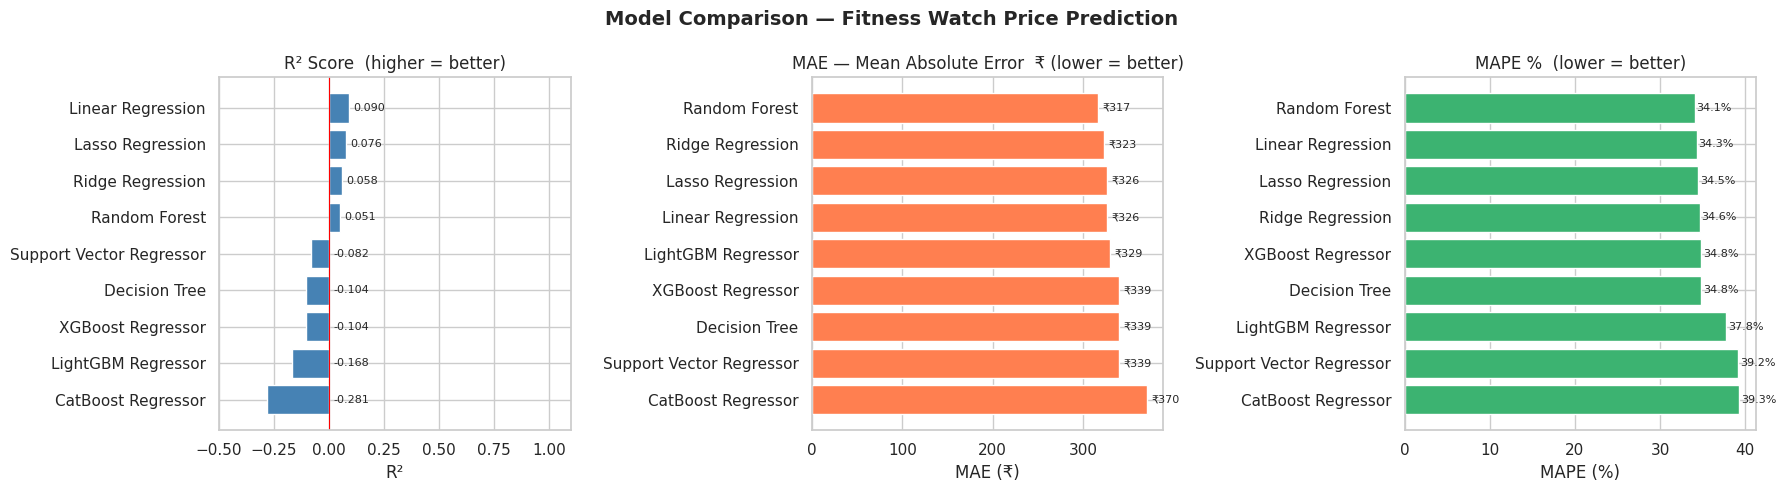

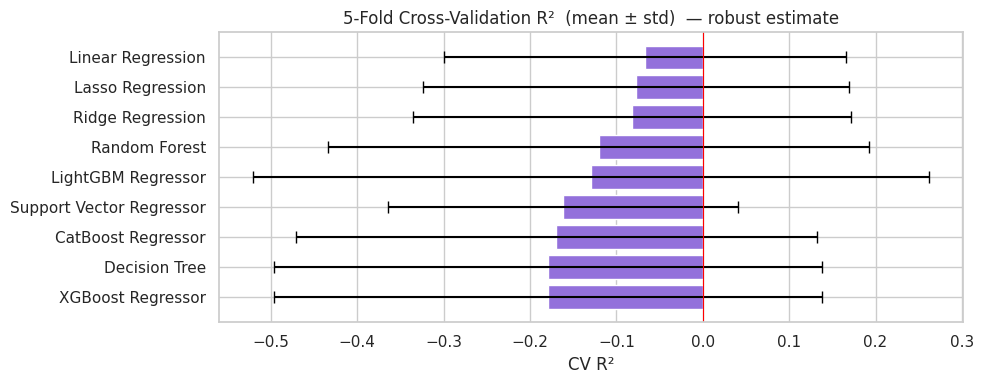

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sort for consistent bar ordering across all three panels
sorted_df = results_df.sort_values('R² Score', ascending=True)

# R² Score
axes[0].barh(sorted_df['Model'], sorted_df['R² Score'], color='steelblue')
axes[0].set_title('R² Score  (higher = better)')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='red', linewidth=0.8)
axes[0].set_xlim([-0.5, 1.1])
for i, v in enumerate(sorted_df['R² Score']):
    axes[0].text(max(v, 0) + 0.02, i, f'{v:.3f}', va='center', fontsize=8)

# MAE (₹)
sorted_mae = results_df.sort_values('MAE (₹)', ascending=False)
axes[1].barh(sorted_mae['Model'], sorted_mae['MAE (₹)'], color='coral')
axes[1].set_title('MAE — Mean Absolute Error  ₹ (lower = better)')
axes[1].set_xlabel('MAE (₹)')
for i, v in enumerate(sorted_mae['MAE (₹)']):
    axes[1].text(v + 5, i, f'₹{v:.0f}', va='center', fontsize=8)

# MAPE (%)
sorted_mape = results_df.sort_values('MAPE (%)', ascending=False)
axes[2].barh(sorted_mape['Model'], sorted_mape['MAPE (%)'], color='mediumseagreen')
axes[2].set_title('MAPE %  (lower = better)')
axes[2].set_xlabel('MAPE (%)')
for i, v in enumerate(sorted_mape['MAPE (%)']):
    axes[2].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Model Comparison — Fitness Watch Price Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cross-validation comparison
fig, ax = plt.subplots(figsize=(10, 4))
cv_sorted = results_df.sort_values('CV R² (mean)', ascending=True)
ax.barh(cv_sorted['Model'], cv_sorted['CV R² (mean)'],
        xerr=cv_sorted['CV R² (std)'], color='mediumpurple',
        error_kw=dict(ecolor='black', capsize=4))
ax.set_title('5-Fold Cross-Validation R²  (mean ± std)  — robust estimate')
ax.set_xlabel('CV R²')
ax.axvline(0, color='red', linewidth=0.8)
plt.tight_layout()
plt.show()

## **STEP 7 — Feature Importance Plot (Best Model)**

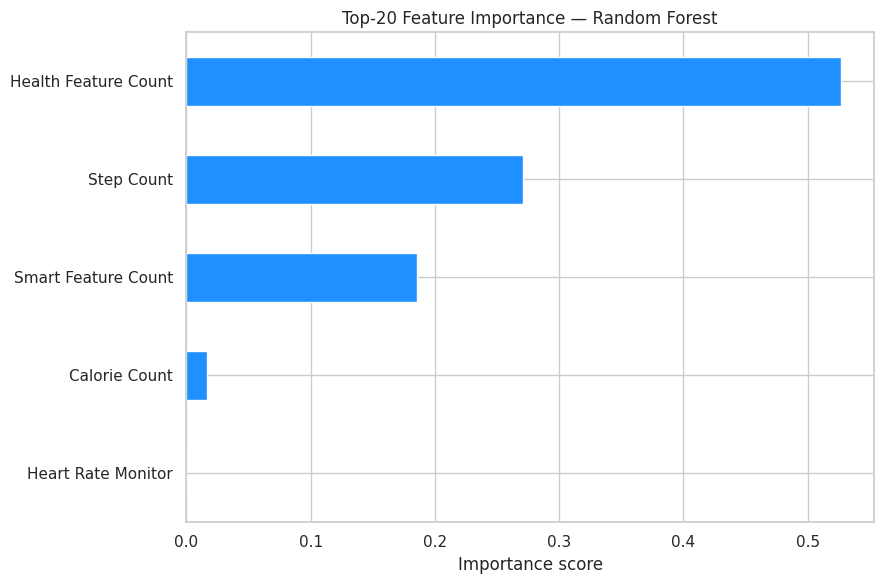

In [8]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_,
                   index=feature_columns).sort_values(ascending=True)
    # Show top 20 to avoid cramping when one-hot adds many columns
    fi_top = fi.tail(20)
    plt.figure(figsize=(9, 6))
    fi_top.plot(kind='barh', color='dodgerblue')
    plt.title(f'Top-20 Feature Importance — {best_model_name}')
    plt.xlabel('Importance score')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    fi = pd.Series(best_model.coef_, index=feature_columns).sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    fi.plot(kind='barh', color='coral')
    plt.title(f'Coefficients — {best_model_name}')
    plt.xlabel('Coefficient value')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

else:
    print(f'{best_model_name} does not expose feature importance directly.')
    print('Consider using SHAP (pip install shap) for model-agnostic explanations.')

## **STEP 8 — Actual vs Predicted & Residual Plots**

> **IMPROVED:** Residual plot added. A well-behaved model shows residuals scattered randomly
> around zero. Patterns (fan shape, trend) signal heteroscedasticity or non-linearity.

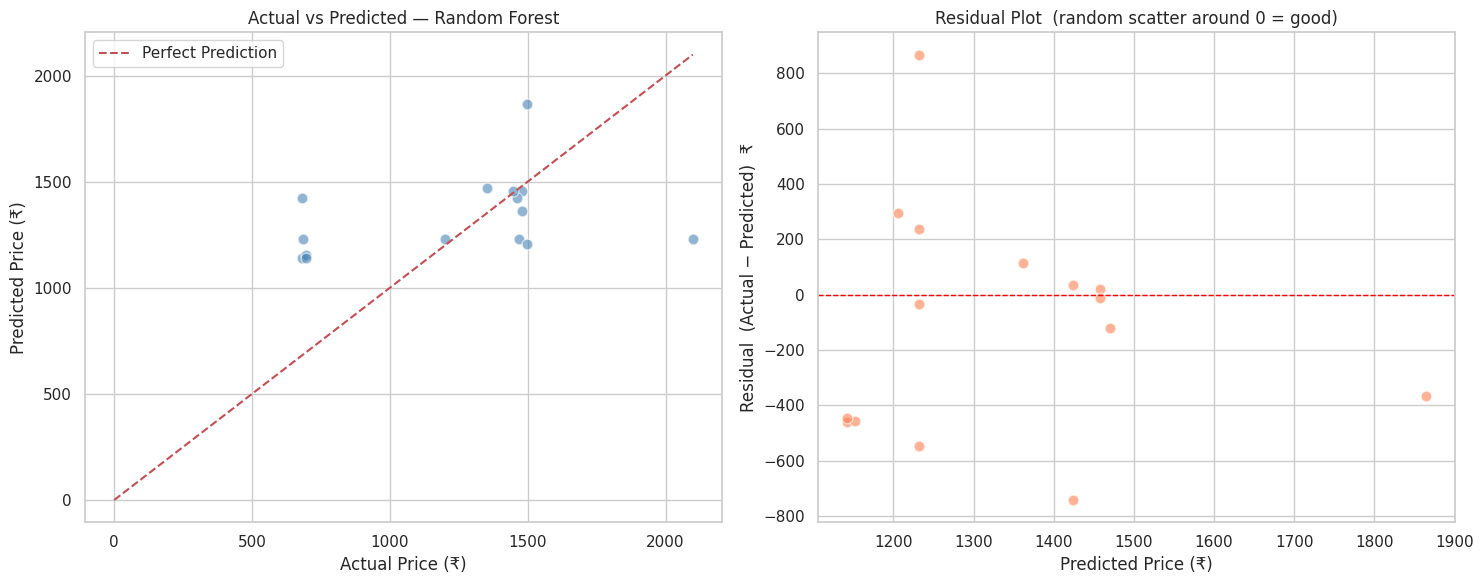

Best model: Random Forest
R²  : 0.0507
MAE : ₹316.67
RMSE: ₹410.48


In [9]:
y_pred_best = best_model.predict(X_test)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Actual vs Predicted ─────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='steelblue',
                edgecolors='white', s=60)
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₹)')
axes[0].set_ylabel('Predicted Price (₹)')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')
axes[0].legend()

# ── Right: Residual plot ──────────────────────────────────────────────────
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='coral',
                edgecolors='white', s=60)
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Price (₹)')
axes[1].set_ylabel('Residual  (Actual − Predicted)  ₹')
axes[1].set_title('Residual Plot  (random scatter around 0 = good)')

plt.tight_layout()
plt.show()

print(f'Best model: {best_model_name}')
print(f'R²  : {r2_score(y_test, y_pred_best):.4f}')
print(f'MAE : ₹{mean_absolute_error(y_test, y_pred_best):.2f}')
print(f'RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}')

## **STEP 8b — Sanity Check: Manual Prediction Test**

> **FIXED:** This cell was originally placed *before* the model training loop (Step 5),
> so `best_model` was undefined and it would crash. It is now placed after training.

> **FIXED:** Column names updated to match one-hot encoding. Instead of integer codes,
> we set the relevant binary column to 1 and leave all others at 0.

In [10]:
# Build two test watches and compare their predicted prices
# Works for both one-hot and label-encoded feature sets

def make_watch(overrides: dict) -> pd.DataFrame:
    """Create a single-row DataFrame of zeros then apply overrides."""
    row = {col: 0 for col in feature_columns}
    row.update(overrides)
    return pd.DataFrame([row])[feature_columns]

if encoding_mode == 'one-hot':
    # One-hot: set the matching binary column to 1
    low_watch  = make_watch({
        'Health Feature Count': 1, 'Smart Feature Count': 1,
        'Calorie Count': 0, 'Step Count': 0, 'Heart Rate Monitor': 1,
        'Brand_GOBOULT': 1,           # flip the GOBOULT column on
        'Strap Type_Metal': 1,
        'Display Type_AMOLED': 1,
        'parent_company_GOBOULT': 1,
    })
    high_watch = make_watch({
        'Health Feature Count': 5, 'Smart Feature Count': 2,
        'Calorie Count': 1, 'Step Count': 1, 'Heart Rate Monitor': 1,
        'Brand_Fastrack': 1,
        'Strap Type_Metal': 1,
        'Display Type_AMOLED': 1,
        'parent_company_Titan Company Limited': 1,
    })
else:
    # Legacy label-encoded path
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    def encode(col_raw, val):
        le.fit(df[col_raw].fillna('Unknown').astype(str))
        return int(np.where(le.classes_ == val)[0][0]) if val in le.classes_ else 0
    low_watch  = make_watch({
        'Health Feature Count': 1, 'Smart Feature Count': 1,
        'Calorie Count': 0, 'Step Count': 0, 'Heart Rate Monitor': 1,
        'Brand_encoded':          encode('Brand', 'GOBOULT'),
        'Strap Type_encoded':     encode('Strap Type', 'Metal'),
        'Display Type_encoded':   encode('Display Type', 'AMOLED'),
        'parent_company_encoded': encode('parent_company', 'GOBOULT'),
    })
    high_watch = make_watch({
        'Health Feature Count': 5, 'Smart Feature Count': 2,
        'Calorie Count': 1, 'Step Count': 1, 'Heart Rate Monitor': 1,
        'Brand_encoded':          encode('Brand', 'Fastrack'),
        'Strap Type_encoded':     encode('Strap Type', 'Metal'),
        'Display Type_encoded':   encode('Display Type', 'AMOLED'),
        'parent_company_encoded': encode('parent_company', 'Titan Company Limited'),
    })

print(f'Low-feature watch  (GOBOULT,  1 health feature) → ₹{best_model.predict(low_watch)[0]:.0f}')
print(f'High-feature watch (Fastrack, 5 health features) → ₹{best_model.predict(high_watch)[0]:.0f}')
print('\n(A well-fitted model should predict a higher price for the high-feature watch.)')

Low-feature watch  (GOBOULT,  1 health feature) → ₹1200
High-feature watch (Fastrack, 5 health features) → ₹1090

(A well-fitted model should predict a higher price for the high-feature watch.)


## **STEP 9 — Install pyngrok & Flask for Deployment**

In [11]:
!pip install pyngrok flask --quiet
!wget -q -c -nc https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -qq -n ngrok-stable-linux-amd64.zip
!mv ngrok /usr/local/bin/ 2>/dev/null || true

## **STEP 10 — Set ngrok Auth Token**
1. Sign up free at https://dashboard.ngrok.com/signup
2. Copy your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
3. In Colab → left panel → 🔑 Secrets → Add secret: Name = `NGROK_AUTH_TOKEN`, Value = your token
4. Enable 'Notebook access' toggle, then run the cell below

In [12]:
from google.colab import userdata
from pyngrok import ngrok

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print('✅ Ngrok authtoken set successfully.')
else:
    print('❌ NGROK_AUTH_TOKEN not found. Please add it to Colab Secrets.')

✅ Ngrok authtoken set successfully.


## **STEP 11 — Launch Flask API + Beautiful Frontend**

> **FIXED:** The HTML form previously sent `Brand_encoded` / `Strap Type_encoded` etc. as
> integer codes (`data-brand="5"`). With one-hot encoding the backend expects binary columns
> (`Brand_GameSir=1`, all other `Brand_*=0`). The `/predict` endpoint now builds the full
> one-hot feature vector server-side from the brand/strap/display name strings sent by the UI.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify, render_template_string
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(5000)
print(f"🌐 App is live at: {public_url}")

app = Flask(__name__)

# Snapshot of column names and best model captured at training time
_feature_columns = feature_columns   # list set in Step 3
_best_model      = best_model
_encoding_mode   = encoding_mode     # 'one-hot' or 'label-encoded'

# ── Helper: build feature vector from UI payload ────────────────────────────
def build_input(data: dict) -> pd.DataFrame:
    """
    Accept a dict with:
      - numeric keys (Health Feature Count, Smart Feature Count, …)
      - 'brand_name', 'strap_name', 'display_name', 'parent_name'  (string names)
    Returns a single-row DataFrame aligned to _feature_columns.
    """
    row = {col: 0 for col in _feature_columns}

    # Copy numeric / boolean features directly
    for key in ['Health Feature Count', 'Smart Feature Count',
                'Calorie Count', 'Step Count', 'Heart Rate Monitor']:
        if key in data:
            row[key] = int(data[key])

    if _encoding_mode == 'one-hot':
        # Flip the matching binary column to 1
        for prefix, name_key in [
            ('Brand_',           'brand_name'),
            ('Strap Type_',      'strap_name'),
            ('Display Type_',    'display_name'),
            ('parent_company_',  'parent_name'),
        ]:
            name = data.get(name_key, '')
            col  = prefix + name
            if col in row:
                row[col] = 1
            # If unseen brand: leave all brand columns 0 (reference category)
    else:
        # Legacy integer encoding — accept numeric codes directly
        for key in ['Brand_encoded', 'Strap Type_encoded',
                    'Display Type_encoded', 'parent_company_encoded']:
            if key in data:
                row[key] = int(data[key])

    return pd.DataFrame([row])[_feature_columns]


html_form = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>FitWatch ML — Price Predictor</title>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: 'Inter', sans-serif;
      background: linear-gradient(135deg, #f5f0ff 0%, #fce4f0 50%, #e8f4ff 100%);
      min-height: 100vh;
      display: flex;
      align-items: center;
      justify-content: center;
      padding: 24px;
    }
    .wrapper {
      width: 100%;
      max-width: 1080px;
      display: grid;
      grid-template-columns: 1fr 380px;
      gap: 24px;
      align-items: start;
    }
    .left-panel {
      background: #fff;
      border-radius: 24px;
      padding: 36px;
      box-shadow: 0 8px 40px rgba(0,0,0,0.08);
    }
    .brand-bar { display: flex; align-items: center; gap: 10px; margin-bottom: 28px; }
    .logo { font-size: 22px; font-weight: 800; color: #1a1a2e; }
    .logo span { color: #7c3aed; }
    .badge { background: #dcfce7; color: #16a34a; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 20px; margin-left: auto; }
    .hero-title { font-size: 38px; font-weight: 800; color: #1a1a2e; line-height: 1.15; margin-bottom: 8px; }
    .hero-sub { font-size: 14px; color: #6b7280; margin-bottom: 32px; }
    .section-title { font-size: 12px; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; color: #9ca3af; margin-bottom: 12px; }
    .chip-group { display: flex; flex-wrap: wrap; gap: 8px; margin-bottom: 28px; }
    .chip { padding: 7px 16px; border-radius: 20px; border: 2px solid #e5e7eb; background: #fff;
            font-size: 13px; font-weight: 500; color: #374151; cursor: pointer; transition: all 0.18s; }
    .chip:hover { border-color: #7c3aed; color: #7c3aed; }
    .chip.active { background: #7c3aed; border-color: #7c3aed; color: #fff; }
    .slider-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 28px; }
    .slider-box label { display: flex; justify-content: space-between; font-size: 13px; font-weight: 500; color: #374151; margin-bottom: 6px; }
    .slider-box label span { font-weight: 700; color: #7c3aed; }
    input[type=range] { width: 100%; accent-color: #7c3aed; height: 6px; cursor: pointer; }
    .toggle-group { display: flex; gap: 8px; margin-bottom: 28px; flex-wrap: wrap; }
    .toggle-btn { padding: 8px 18px; border-radius: 10px; border: 2px solid #e5e7eb; background: #f9fafb;
                  font-size: 13px; font-weight: 500; color: #374151; cursor: pointer; transition: all 0.18s; }
    .toggle-btn:hover { border-color: #7c3aed; }
    .toggle-btn.active { background: #ede9fe; border-color: #7c3aed; color: #7c3aed; font-weight: 700; }
    .predict-btn { width: 100%; padding: 16px; border: none; border-radius: 14px;
                   background: linear-gradient(135deg, #7c3aed, #a855f7); color: #fff; font-size: 16px;
                   font-weight: 700; cursor: pointer; transition: transform 0.15s, box-shadow 0.15s;
                   box-shadow: 0 4px 20px rgba(124,58,237,0.35); }
    .predict-btn:hover { transform: translateY(-2px); box-shadow: 0 8px 28px rgba(124,58,237,0.45); }
    .right-panel { display: flex; flex-direction: column; gap: 16px; }
    .result-card { background: #fff; border-radius: 24px; padding: 28px; box-shadow: 0 8px 40px rgba(0,0,0,0.08); }
    .result-label { font-size: 12px; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; color: #9ca3af; margin-bottom: 6px; }
    .watch-visual { display: flex; flex-direction: column; align-items: center; margin: 12px 0 20px; }
    .watch-face { width: 130px; height: 150px; background: linear-gradient(160deg, #1e1b4b, #312e81);
                  border-radius: 30px; display: flex; flex-direction: column; align-items: center;
                  justify-content: center; box-shadow: 0 12px 40px rgba(30,27,75,0.4); gap: 6px; }
    .watch-brand-label { font-size: 11px; color: rgba(255,255,255,0.5); font-weight: 500; letter-spacing: 1px; }
    .watch-price-label { font-size: 11px; color: rgba(255,255,255,0.6); }
    .watch-price-big { font-size: 24px; font-weight: 800; color: #fff; letter-spacing: -1px; }
    .watch-icons { display: flex; gap: 8px; margin-top: 4px; }
    .watch-icon { background: rgba(255,255,255,0.15); color: #fff; font-size: 9px;
                  font-weight: 700; padding: 3px 7px; border-radius: 6px; }
    .price-big { font-size: 36px; font-weight: 800; color: #1a1a2e; }
    .price-range { font-size: 14px; color: #9ca3af; margin-left: 6px; }
    .confidence-section { margin-top: 16px; }
    .confidence-row { display: flex; justify-content: space-between; font-size: 13px; color: #6b7280; margin-bottom: 6px; }
    .confidence-row strong { color: #1a1a2e; }
    .conf-bar-bg { height: 8px; background: #f3f4f6; border-radius: 10px; overflow: hidden; }
    .conf-bar-fill { height: 100%; background: linear-gradient(90deg, #7c3aed, #a855f7, #ec4899);
                     border-radius: 10px; transition: width 0.6s ease; }
    .info-pills { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 10px; margin-top: 16px; }
    .info-pill { background: #f9fafb; border-radius: 12px; padding: 10px 8px; text-align: center; }
    .info-pill .pill-label { font-size: 10px; text-transform: uppercase; letter-spacing: 0.5px;
                             color: #9ca3af; font-weight: 600; }
    .info-pill .pill-value { font-size: 14px; font-weight: 700; color: #1a1a2e; margin-top: 2px; }
    .placeholder-msg { text-align: center; padding: 24px; color: #9ca3af; font-size: 14px; }
    .error-msg { color: #ef4444; text-align: center; font-size: 13px; padding: 12px; }
    .data-note { background: #fffbeb; border: 1px solid #fcd34d; border-radius: 10px;
                 padding: 10px 14px; font-size: 12px; color: #92400e; margin-top: 12px; }
    @media (max-width: 760px) { .wrapper { grid-template-columns: 1fr; } .slider-grid { grid-template-columns: 1fr; } }
  </style>
</head>
<body>
<div class="wrapper">

  <!-- LEFT -->
  <div class="left-panel">
    <div class="brand-bar">
      <div class="logo">FitWatch<span>ML</span></div>
      <div style="font-size:12px;color:#9ca3af;">Smartwatch pricing engine</div>
      <div class="badge">● Live ML</div>
    </div>

    <h1 class="hero-title">Predict the price<br/>of a fitness watch.</h1>
    <p class="hero-sub">Tune watch attributes and get an instant ML-powered price estimate.</p>

    <!-- FIXED: chips now send brand name strings, not integer codes -->
    <div class="section-title">Brand</div>
    <div class="chip-group" id="brandGroup">
      <button class="chip active"  data-brand="GameSir"   data-parent="GameSir"             onclick="selectChip(this,'brandGroup')">GameSir</button>
      <button class="chip"         data-brand="Fastrack"  data-parent="Titan Company Limited" onclick="selectChip(this,'brandGroup')">Fastrack</button>
      <button class="chip"         data-brand="Nervfit"   data-parent="Nervfit"              onclick="selectChip(this,'brandGroup')">Nervfit</button>
      <button class="chip"         data-brand="GOBOULT"   data-parent="GOBOULT"              onclick="selectChip(this,'brandGroup')">GOBOULT</button>
      <button class="chip"         data-brand="Fire-Boltt" data-parent="Fire-Boltt"          onclick="selectChip(this,'brandGroup')">Fire-Boltt</button>
      <button class="chip"         data-brand="Maxima"    data-parent="Maxima"               onclick="selectChip(this,'brandGroup')">Maxima</button>
      <button class="chip"         data-brand="MBS"       data-parent="MBS"                  onclick="selectChip(this,'brandGroup')">MBS</button>
      <button class="chip"         data-brand="Melbon"    data-parent="Melbon"               onclick="selectChip(this,'brandGroup')">Melbon</button>
      <button class="chip"         data-brand="PunnkFunnk" data-parent="PunnkFunnk"          onclick="selectChip(this,'brandGroup')">PunnkFunnk</button>
      <button class="chip"         data-brand="sweetex"   data-parent="sweetex"              onclick="selectChip(this,'brandGroup')">sweetex</button>
    </div>

    <!-- FIXED: send display name string -->
    <div class="section-title">Display Type</div>
    <div class="toggle-group" id="displayGroup">
      <button class="toggle-btn active" data-val="AMOLED"  onclick="selectToggle(this,'displayGroup')">AMOLED</button>
      <button class="toggle-btn"        data-val="LCD/TFT" onclick="selectToggle(this,'displayGroup')">LCD/TFT</button>
    </div>

    <!-- FIXED: send strap name string -->
    <div class="section-title">Strap Type</div>
    <div class="toggle-group" id="strapGroup">
      <button class="toggle-btn"        data-val="Leather" onclick="selectToggle(this,'strapGroup')">Leather</button>
      <button class="toggle-btn active" data-val="Metal"   onclick="selectToggle(this,'strapGroup')">Metal</button>
    </div>

    <!-- Sliders -->
    <div class="slider-grid">
      <div class="slider-box">
        <label>Health Features <span id="hfVal">3</span>/5</label>
        <input type="range" id="healthFeatures" min="0" max="5" value="3"
               oninput="document.getElementById('hfVal').textContent=this.value">
      </div>
      <div class="slider-box">
        <label>Smart Features <span id="sfVal">1</span>/2</label>
        <input type="range" id="smartFeatures" min="0" max="2" value="1"
               oninput="document.getElementById('sfVal').textContent=this.value">
      </div>
      <div class="slider-box">
        <label>Calorie Tracking <span id="calVal">Yes</span></label>
        <input type="range" id="calorieCount" min="0" max="1" value="1" step="1"
               oninput="document.getElementById('calVal').textContent=this.value==1?'Yes':'No'">
      </div>
      <div class="slider-box">
        <label>Step Tracking <span id="stepVal">Yes</span></label>
        <input type="range" id="stepCount" min="0" max="1" value="1" step="1"
               oninput="document.getElementById('stepVal').textContent=this.value==1?'Yes':'No'">
      </div>
    </div>

    <button class="predict-btn" onclick="predict()">🔮 Predict Price</button>

    <div class="data-note">
      ⚠️ Note: Predictions may cluster in a narrow price band because Flipkart listing prices
      contain noise (swapped / inflated values). The IQR-based cleaning in the updated EDA
      notebook reduces this effect.
    </div>
  </div>

  <!-- RIGHT -->
  <div class="right-panel">
    <div class="result-card">
      <div class="result-label">ML Estimate</div>
      <div class="watch-visual">
        <div class="watch-face">
          <div class="watch-brand-label" id="watchBrand">GameSir</div>
          <div class="watch-price-label">Predicted</div>
          <div class="watch-price-big" id="watchPrice">—</div>
          <div class="watch-icons">
            <span class="watch-icon">HR</span>
            <span class="watch-icon">BT</span>
            <span class="watch-icon">O₂</span>
          </div>
        </div>
      </div>
      <div id="resultArea">
        <div class="placeholder-msg">👆 Click Predict Price to see the estimate</div>
      </div>
    </div>
  </div>

</div>

<script>
  let activeBrandName  = 'GameSir';
  let activeParentName = 'GameSir';

  function selectChip(el, groupId) {
    document.querySelectorAll(`#${groupId} .chip`).forEach(b => b.classList.remove('active'));
    el.classList.add('active');
    activeBrandName  = el.dataset.brand;
    activeParentName = el.dataset.parent;
    document.getElementById('watchBrand').textContent = el.textContent.trim();
  }

  function selectToggle(el, groupId) {
    document.querySelectorAll(`#${groupId} .toggle-btn`).forEach(b => b.classList.remove('active'));
    el.classList.add('active');
  }

  function getToggleVal(groupId) {
    return document.querySelector(`#${groupId} .toggle-btn.active`)?.dataset.val ?? '';
  }

  async function predict() {
    const btn = document.querySelector('.predict-btn');
    btn.textContent = '⏳ Predicting...';
    btn.disabled = true;

    // FIXED: send string names so the backend can build the one-hot vector
    const payload = {
      'Health Feature Count' : parseFloat(document.getElementById('healthFeatures').value),
      'Smart Feature Count'  : parseFloat(document.getElementById('smartFeatures').value),
      'Calorie Count'        : parseFloat(document.getElementById('calorieCount').value),
      'Step Count'           : parseFloat(document.getElementById('stepCount').value),
      'Heart Rate Monitor'   : 1,
      'brand_name'           : activeBrandName,
      'strap_name'           : getToggleVal('strapGroup'),
      'display_name'         : getToggleVal('displayGroup'),
      'parent_name'          : activeParentName
    };

    try {
      const res  = await fetch('/predict', {
        method : 'POST',
        headers: { 'Content-Type': 'application/json' },
        body   : JSON.stringify(payload)
      });
      const data = await res.json();

      if (res.ok) {
        const price   = Math.round(data.prediction);
        const low     = Math.round(price * 0.88);
        const high    = Math.round(price * 1.12);
        const conf    = Math.min(92, Math.max(55, 85 - Math.abs(price - 1400) / 30));
        const segment = price < 1000 ? 'Budget' : price < 2000 ? 'Mid' : 'Premium';
        const demand  = parseInt(document.getElementById('healthFeatures').value) >= 4 ? 'High' : 'Medium';
        const disp    = getToggleVal('displayGroup');

        document.getElementById('watchPrice').textContent =
          '\u20B9' + price.toLocaleString('en-IN');

        document.getElementById('resultArea').innerHTML = `
          <div style="margin-top:4px;">
            <span class="price-big">\u20B9${price.toLocaleString('en-IN')}</span>
            <span class="price-range">\u20B9${low.toLocaleString('en-IN')}–\u20B9${high.toLocaleString('en-IN')}</span>
          </div>
          <div class="confidence-section">
            <div class="confidence-row">
              <span>Market position</span>
              <strong>${conf.toFixed(0)}% confidence</strong>
            </div>
            <div class="conf-bar-bg">
              <div class="conf-bar-fill" style="width:${conf}%"></div>
            </div>
          </div>
          <div class="info-pills">
            <div class="info-pill">
              <div class="pill-label">Segment</div>
              <div class="pill-value">${segment}</div>
            </div>
            <div class="info-pill">
              <div class="pill-label">Demand</div>
              <div class="pill-value">${demand}</div>
            </div>
            <div class="info-pill">
              <div class="pill-label">Display</div>
              <div class="pill-value">${disp}</div>
            </div>
          </div>
        `;
      } else {
        document.getElementById('resultArea').innerHTML =
          `<div class="error-msg">Error: ${data.error}</div>`;
      }
    } catch(e) {
      document.getElementById('resultArea').innerHTML =
        `<div class="error-msg">Network error: ${e}</div>`;
    }

    btn.textContent = '🔮 Predict Price';
    btn.disabled = false;
  }
</script>
</body>
</html>
"""

@app.route("/predict", methods=["POST"])
def predict_route():
    try:
        data     = request.get_json(force=True)
        input_df = build_input(data)
        pred     = _best_model.predict(input_df)
        pred_val = float(np.maximum(0, pred[0]))
        return jsonify({'prediction': pred_val})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route("/", methods=["GET"])
def root():
    return render_template_string(html_form)

print("🚀 Starting Flask... visit the ngrok URL above")
app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)


🌐 App is live at: NgrokTunnel: "https://defiling-latter-amaze.ngrok-free.dev" -> "http://localhost:5000"
🚀 Starting Flask... visit the ngrok URL above
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [06/May/2026 04:59:11] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 04:59:21] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 04:59:24] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 04:59:53] "POST /predict HTTP/1.1" 200 -
